# Project Two: CNN-Based Alphanumeric Character Recognition (0–9, a–z)

### Project Overview

This project builds a 36-class Convolutional Neural Network (CNN) that classifies:

Digits: 0–9 (from MNIST)

Letters: a–z (from EMNIST Letters split)

The final model predicts one of:

$$ [{0,…,9,a,…,z}] $$

Total classes:

$$10 (digits)+26 (letters)=36$$


### Import libaries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Sequential
import gzip
from typing import cast

### Data loading and preprocessing
The function `load_mnist(path: str)` loads pre-saved .npz(numpy compressed format) MNIST file containing:

- x_train → (60000, 28, 28)
- y_train → (60000,)
- x_test → (10000, 28, 28)
- y_test → (10000,)

the return value is a size 4 tuple of numpy array.

The function `load_emnistimages(filepath: str)` loads the .IDX (Binary Format Structure) of the EMNIST image, the return value is a numpy array:
- (num_images, 28 = image width, 28 = image height)

The function `load_emnistilabels(filepath: str)` loads the .IDX (Binary Format Structure) of the EMNIST label, the return value is a numpy array:
- (num_labels,)

In [ ]:
def load_mnist(path: str) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    mnist = np.load(path, allow_pickle=True)
    return mnist['x_train'], mnist['y_train'], mnist['x_test'], mnist['y_test']


def load_emnistimages(filepath: str) -> np.ndarray:
    with gzip.open(filepath, 'rb') as f:
        f.read(4)                            
        num_images = int.from_bytes(cast(bytes, f.read(4)), 'big')
        rows       = int.from_bytes(cast(bytes, f.read(4)), 'big')
        cols       = int.from_bytes(cast(bytes, f.read(4)), 'big')
        buf = cast(bytes, f.read(num_images * rows * cols))
        images = np.frombuffer(buf, dtype=np.uint8)
        images = images.reshape(num_images, rows, cols)
    return images

def load_emnistlabels(filepath: str) -> np.ndarray:
    with gzip.open(filepath, 'rb') as f:
        f.read(4)  
        num_labels = int.from_bytes(cast(bytes, f.read(4)), 'big')
        buf = cast(bytes, f.read(num_labels))
        labels = np.frombuffer(buf, dtype=np.uint8)
    return labels


#### Data Loading
- MNIST dataset (for digits 0-9)
- EMNIST dataset by letters  (for alphabet A-Z,a-z)

In [27]:
DATA_DIR = '../dataset/'
mnist_x_train, mnist_y_train, mnist_x_test, mnist_y_test = load_mnist(DATA_DIR + 'mnist.npz')

print(mnist_x_train.shape)  
print(mnist_y_train.shape)  
print(mnist_x_test.shape)  
print(mnist_y_test.shape) 


emnist_x_train = load_emnistimages(DATA_DIR + 'emnist-letters-train-images-idx3-ubyte.gz')
emnist_y_train = load_emnistlabels(DATA_DIR + 'emnist-letters-train-labels-idx1-ubyte.gz')
emnist_x_test  = load_emnistimages(DATA_DIR + 'emnist-letters-test-images-idx3-ubyte.gz')
emnist_y_test  = load_emnistlabels(DATA_DIR + 'emnist-letters-test-labels-idx1-ubyte.gz')

print(emnist_x_train.shape)  
print(emnist_y_train.shape)  
print(emnist_x_test.shape)  
print(emnist_y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
(124800, 28, 28)
(124800,)
(20800, 28, 28)
(20800,)


#### Dataset Alignment
EMNIST images are rotated relative to MNIST by transposing, the This swaps width and height dimensions:

$$(width = 28, height = 28)→(height = 28, widht = 28) $$

In [28]:
emnist_x_train= np.transpose(emnist_x_train, (0, 2, 1))
emnist_x_test  = np.transpose(emnist_x_test,  (0, 2, 1))

#### Label Remapping
Original EMNIST letters:
$$1–26$$
We shift them so digits remain 0–9:

$$ new \ label = (label - 1) + 10$$

Final label space:
$$MNIST = 0–9→digits$$
$$EMNIST = 10–35→letters$$

In [29]:
emnist_y_train = emnist_y_train - 1 + 10
emnist_y_test  = emnist_y_test - 1 + 10

#### Dataset Merge (MNIST and EMNIST )
Now:


$$X_{train} ∈ R^{N×28×28}$$

Where:

$$𝑁 = 60000 + 124800$$


In [ ]:
X_train = np.concatenate([mnist_x_train, emnist_x_train], axis=0)
Y_train = np.concatenate([mnist_y_train, emnist_y_train], axis=0)
X_test  = np.concatenate([mnist_x_test,  emnist_x_test],  axis=0)
Y_test  = np.concatenate([mnist_y_test,  emnist_y_test],  axis=0)


### Normalization

Pixel range transformation:

$$
[0,255]→[0,1]
$$

In [31]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

#### Tensor Reshaping

CNN requires:

$$(Batch,Height,Width,Channels)$$

where:
- Batch = total number of images processed together
- Height = 28 (the image height)
- Width = 28 (the image width)
- Channels = 1 (the image is greyscale)


In [32]:
X_train = X_train.squeeze()[..., np.newaxis]
X_test = X_test.squeeze()[..., np.newaxis]

(X_train.shape, Y_train.shape), (X_test.shape, Y_test.shape)

(((184800, 28, 28, 1), (184800,)), ((30800, 28, 28, 1), (30800,)))

### Model Architecture 

In [33]:
model = Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(36, activation="softmax"),
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 36)             │         2,340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,940 (484.14 KB)

 Trainable params: 123,940 (484.14 KB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation
- optimizer="adam" -> adaptive gradient decent
- loss="sparse_categorical_crossentropy" -> Because the labels are integers

Loss function:

$$L=−logP(_{ytrue})$$

In [34]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Training

In [35]:
model.fit(
    X_train,
    Y_train,
    batch_size=64,
    epochs=20,
    validation_data=(X_test, Y_test)
)

Epoch 1/20
2888/2888 ━━━━━━━━━━━━━━━━━━━━ 91s 30ms/step - accuracy: 0.7887 - loss: 0.6817 - val_accuracy: 0.8844 - val_loss: 0.3584
Epoch 2/20
2888/2888 ━━━━━━━━━━━━━━━━━━━━ 94s 32ms/step - accuracy: 0.9013 - loss: 0.3022 - val_accuracy: 0.9055 - val_loss: 0.2901
Epoch 3/20
2888/2888 ━━━━━━━━━━━━━━━━━━━━ 87s 30ms/step - accuracy: 0.9186 - loss: 0.2445 - val_accuracy: 0.9144 - val_loss: 0.2663
Epoch 4/20
2888/2888 ━━━━━━━━━━━━━━━━━━━━ 80s 28ms/step - accuracy: 0.9279 - loss: 0.2135 - val_accuracy: 0.9258 - val_loss: 0.2299
Epoch 5/20
2888/2888 ━━━━━━━━━━━━━━━━━━━━ 84s 29ms/step - accuracy: 0.9336 - loss: 0.1923 - val_accuracy: 0.9243 - val_loss: 0.2335
Epoch 6/20
2888/2888 ━━━━━━━━━━━━━━━━━━━━ 84s 29ms/step - accuracy: 0.9394 - loss: 0.1751 - val_accuracy: 0.9295 - val_loss: 0.2161
Epoch 7/20
2888/2888 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.9429 - loss: 0.1631 - val_accuracy: 0.9258 - val_loss: 0.2300
Epoch 8/20
2888/2888 ━━━━━━━━━━━━━━━━━━━━ 85s 29ms/step - accuracy: 0.9455 -

### Evaluation

In [36]:
test_loss, test_accuracy = model.evaluate(X_test, Y_test)
print(f"Test accuracy: {test_accuracy}")

963/963 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9289 - loss: 0.2771
Test accuracy: 0.928928554058075


### Prediction & Visualization

The function `decode_label(label)` does the following mapping:
$$0 → 0, ..., 9 → 9, 10 → a, ..., 35 → z $$

963/963 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step


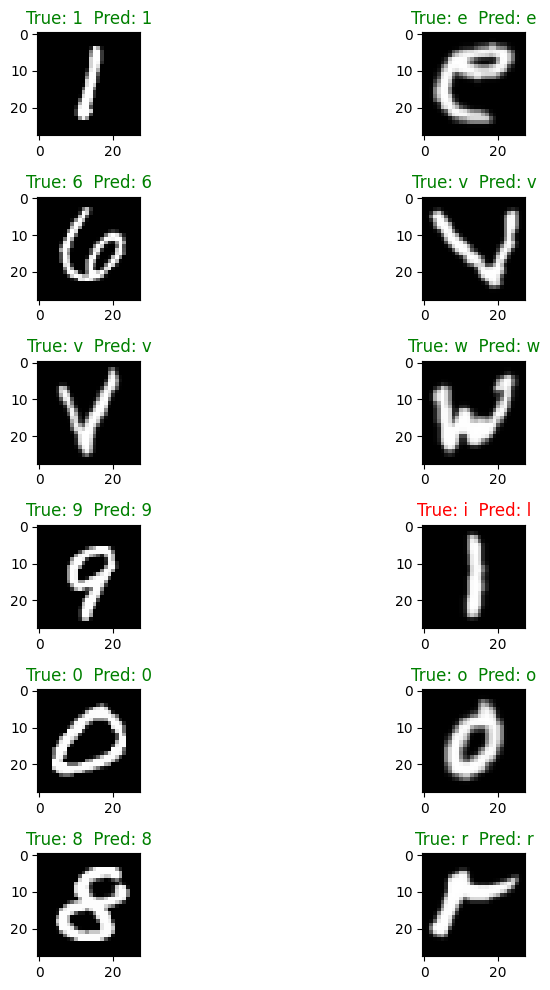

In [37]:
def decode_label(label):
    if label < 10:
        return str(label)               
    return chr(ord('a') + label - 10)


predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)


indices = np.random.choice(len(X_test), 12)

plt.figure(figsize=(10, 10))


for i, idx in enumerate(indices):
    plt.subplot(6, 2, i+1)
    plt.imshow(X_test[idx].squeeze(), cmap='gray')
    
    true_label = Y_test[idx]
    pred_label = predicted_classes[idx]
    
    color = "green" if true_label == pred_label else "red"
    
    plt.title(f"True: {decode_label(true_label)}  Pred: {decode_label(pred_label)}", color=color)
    plt.axis("on")

plt.tight_layout()
plt.show()



### Final Model Summary

Problem Type:

- Multiclass image classification (36 classes)

Input:
$$28×28×1$$

Output:
$$36-dimensional \ probability  \ vector$$

Architecture Type:
- Deep Convolutional Neural Network 